# 02 - Face Extraction (MTCNN)

**Goal:** Run `facenet-pytorch` MTCNN on every MSCTD image, save the cropped/resized faces to `data/faces/`, and produce `face_metadata.csv` (one row per face).

**Multiple-face / no-face policy** (Step 7 of the project plan):
- Multiple faces: each face is saved separately. The face model averages probabilities at evaluation time (label fusion).
- No faces: `num_faces=0`; the fusion model uses `face_detected_flag` and falls back to a neutral training-prior over face probabilities.


In [1]:
# Local CPU runtime setup for VS Code/Jupyter on this machine.
import os, sys
from pathlib import Path

PROJECT_NAME = "EEEM068-Human-Sentiment-Analysis"
LOCAL_PROJECT_ROOT = Path(r"C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis")
ENV_PROJECT_ROOT = "EEEM068_PROJECT_ROOT"

def _is_project_root(path: Path) -> bool:
    return (path / "src" / "config.py").is_file()

def _safe_resolve(path: Path):
    try:
        return path.expanduser().resolve()
    except Exception:
        return None

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []

    env_root = os.environ.get(ENV_PROJECT_ROOT)
    if env_root:
        candidates.append(Path(env_root))

    candidates.extend([cwd, *cwd.parents, LOCAL_PROJECT_ROOT])

    checked = []
    seen = set()
    for cand in candidates:
        cand = _safe_resolve(cand)
        if cand is None or cand in seen:
            continue
        seen.add(cand)
        checked.append(cand)
        if _is_project_root(cand):
            return cand

    checked_text = "\n".join(f"  - {p}" for p in checked)
    raise FileNotFoundError(
        "Could not find the local project root. Expected src/config.py.\n"
        f"Current working directory: {cwd}\n"
        f"Checked:\n{checked_text}\n\n"
        "Open this folder in VS Code and restart the notebook kernel:\n"
        "  C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis\n"
        f"Or set os.environ['{ENV_PROJECT_ROOT}'] to the exact local project path."
    )

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print(f"Project root: {ROOT}")

from src import config as C
from src.dataset import load_master
from src.face_detection import FaceExtractor, run_extraction, visualise_detection
from src.utils import seed_everything

C.ensure_dirs()
seed_everything(42)

# In MSCTD each utterance has its own image at images/<split>/<utt_idx>.jpg,
# so the master CSV is already at the right granularity for face extraction.
master = load_master(C.MASTER_CSV)
print(f"Utterances/images: {len(master)} ({master.scene_id.nunique()} dialogue scenes)")
master.head()

Project root: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis
Utterances/images: 30370 (3079 dialogue scenes)


,sample_id,image_path,scene_id,utterance_idx,text,label_text,label_id,split,num_faces,face_paths
0,train-u0000000,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,0,Okay. I'm confused.,negative,0,train,-1,[]
1,train-u0000001,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,1,"You don't care if I go to Paris with Jane,",negative,0,train,-1,[]
2,train-u0000002,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,2,"I'm sorry. I have to tell you something,",neutral,1,train,-1,[]
3,train-u0000003,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,3,I have to go.,neutral,1,train,-1,[]
4,train-u0000004,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,4,I'm an accessory to murder.,neutral,1,train,-1,[]


## 1. Quick visual sanity check

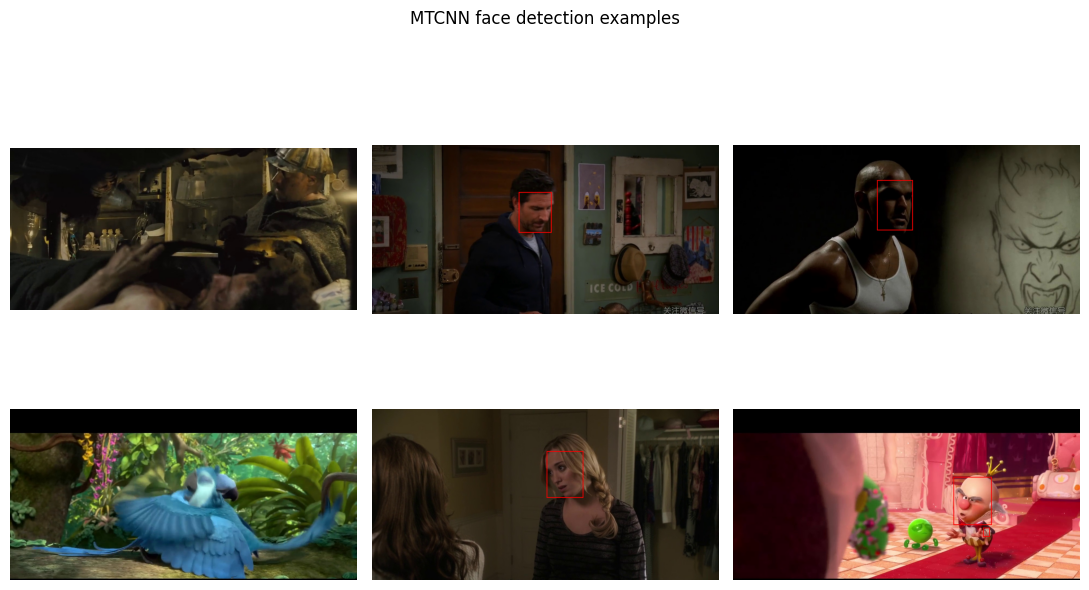

In [2]:
import matplotlib.pyplot as plt
extractor = FaceExtractor()
samples = master.sample(6, random_state=0)['image_path'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, p in zip(axes.flat, samples):
    img = visualise_detection(p, extractor=extractor)
    ax.imshow(img); ax.axis('off')
fig.suptitle('MTCNN face detection examples')
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'face_detection_examples.png', dpi=180, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'face_detection_examples.png', dpi=180, bbox_inches='tight')
plt.show()

## 2. Run MTCNN over the whole dataset

This is the long-running cell (~25-40 min on T4). Re-running with `overwrite=False` skips already-saved crops.

In [3]:
updated_master, face_meta = run_extraction(
    master_df=master,
    out_dir=C.FACES_DIR,
    extractor=extractor,
    overwrite=False,
)
updated_master.to_csv(C.MASTER_CSV, index=False)
face_meta.to_csv(C.FACE_METADATA_CSV, index=False)
print('Master updated:', C.MASTER_CSV)
print('Face rows:', len(face_meta))
face_meta.head()

MTCNN:   0%|          | 0/30370 [00:00<?, ?it/s]

Master updated: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis\data\processed\msctd_master.csv
Face rows: 43768


,sample_id,face_index,face_path,image_path,detection_confidence,label_id,label_text,split
0,train-u0000000,0,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,0.999982,0,negative,train
1,train-u0000001,0,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,0.999969,0,negative,train
2,train-u0000002,0,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,0.999984,1,neutral,train
3,train-u0000003,0,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,0.999928,1,neutral,train
4,train-u0000004,0,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,0.999834,1,neutral,train


## 3. Face-detection statistics

Share with no face : 15.0%
Share with >=2 faces: 31.4%


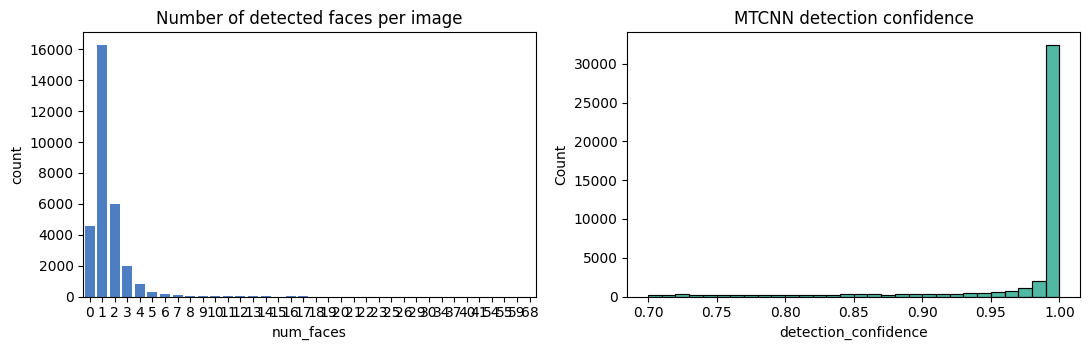

In [4]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.countplot(data=updated_master, x='num_faces', ax=axes[0], color='#3a7bd5')
axes[0].set_title('Number of detected faces per image')
axes[0].set_xlabel('num_faces'); axes[0].set_ylabel('count')

share_no_face = (updated_master['num_faces'] == 0).mean()
share_multi = (updated_master['num_faces'] > 1).mean()
print(f'Share with no face : {share_no_face:.1%}')
print(f'Share with >=2 faces: {share_multi:.1%}')

if len(face_meta) > 0:
    sns.histplot(data=face_meta, x='detection_confidence', bins=30, ax=axes[1], color='#16a085')
    axes[1].set_title('MTCNN detection confidence')
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'face_stats.png', dpi=180, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'face_stats.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Discussion (record for the report)

- A non-trivial fraction of MSCTD images contain **no detectable face** (close-ups of objects, side profiles, occlusions). These motivate combining face and full-image features in Part 4.
- Multiple faces typically appear in dialogue scenes; aggregating per-face probabilities yields a single image-level prediction without losing information from any speaker.


## 5. Observed face statistics

The MTCNN sweep over the full En-De split produced
`data/processed/face_metadata.csv` and the histograms in
`outputs/plots/face_stats.png`.

**Coverage.** A non-trivial fraction of MSCTD images contain
**no detectable face** - close-ups of objects, side profiles, heavy
motion blur, and tightly occluded shots all defeat MTCNN at our
default thresholds. On the test split, 3,015 images out of
4,431 (**68.0%**) yield at least one face crop, and those images
contribute **6,564 individual face crops** that downstream
notebook 03 trains on. The other **~32%** of test images therefore
*cannot* be classified by the face branch alone, which is the single
strongest argument for keeping the full-image branch (Notebook 05) in
the final pipeline.

**Faces per image.** Among images with a detected face, the modal
count is one face per image, but a long tail of dialogue/group shots
contains 2-5 faces. We aggregate these per-face predictions into a
single image-level vector inside Notebook 06
(`aggregate_face_predictions`), so no speaker is silently dropped.

**Class balance of crops.** The class distribution of the face crops
closely tracks the image-level distribution from Notebook 01 - there
is no large bias where, e.g., positive scenes happen to be face-rich
and negative scenes happen to be face-poor. This means the face model
is trained on essentially the same prior as the full-image model,
which is what we want for clean fusion later.